<a href="https://colab.research.google.com/github/omerbibin/pneumonia-detection-cxr/blob/main/Week04_Baseline_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# === Drive mount ===
from google.colab import drive
drive.mount('/content/drive')

# === Imports ===
import os, shutil, json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

import tensorflow as tf
from tensorflow.keras import layers, Sequential, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

# === Reproducibility (same seed as Week 3) ===
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# === Paths ===
PROJECT_ROOT  = Path("/content/drive/MyDrive/PneumoniaDetection")
MANIFEST_PATH = PROJECT_ROOT / "reports" / "manifest.csv"
MODELS_DIR    = PROJECT_ROOT / "models"
FIGURES_DIR   = PROJECT_ROOT / "reports" / "figures"
HISTORY_DIR   = PROJECT_ROOT / "reports" / "history"
for d in (MODELS_DIR, FIGURES_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)

# === Restore raw data to fast local SSD if cold runtime ===
DRIVE_RAW  = PROJECT_ROOT / "data" / "raw" / "chest_xray"
LOCAL_DATA = Path("/content/chest_xray")
if not LOCAL_DATA.exists():
    print("Cold runtime detected — copying raw data from Drive (~5-10 min)...")
    shutil.copytree(DRIVE_RAW, LOCAL_DATA)
    print("Done.")
else:
    print("Raw data already present at:", LOCAL_DATA)

# === Load manifest (the canonical source of truth from Week 3) ===
manifest = pd.read_csv(MANIFEST_PATH)
print(f"\nManifest loaded: {len(manifest)} rows")

# === Rebuild tf.data.Dataset objects from manifest ===
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

def make_dataset(split_name: str, shuffle: bool):
    """Build a tf.data pipeline directly from manifest filepaths."""
    sub    = manifest[manifest["split"] == split_name]
    paths  = sub["filepath"].values
    labels = (sub["class"] == "PNEUMONIA").astype(np.float32).values  # NORMAL=0, PNEU=1

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=RANDOM_SEED,
                        reshuffle_each_iteration=True)

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)        # 3-channel for transfer learning later
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0             # Normalize to [0, 1]
        return img, label

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset("train_split",  shuffle=True)
val_ds   = make_dataset("val_split",    shuffle=False)
test_ds  = make_dataset("test",         shuffle=False)

# === Smoke test ===
xb, yb = next(iter(train_ds))
print(f"\nBatch shape: {xb.shape}  (expect (32, 224, 224, 3))")
print(f"Pixel range: [{xb.numpy().min():.3f}, {xb.numpy().max():.3f}]  (expect [0, 1])")
print(f"Label dist in batch: {int(yb.numpy().sum())}/{len(yb)} are PNEUMONIA")

# === GPU check (training requires it) ===
print("\nGPU available:", bool(tf.config.list_physical_devices("GPU")))
print("If False → Runtime > Change runtime type > T4 GPU, then re-run from Cell 0.")

Mounted at /content/drive
Cold runtime detected — copying raw data from Drive (~5-10 min)...
Done.

Manifest loaded: 5856 rows

Batch shape: (32, 224, 224, 3)  (expect (32, 224, 224, 3))
Pixel range: [0.000, 1.000]  (expect [0, 1])
Label dist in batch: 21/32 are PNEUMONIA

GPU available: True
If False → Runtime > Change runtime type > T4 GPU, then re-run from Cell 0.


In [ ]:
# Pull the labels for train_split only — we never use val/test for weight calculation
train_labels = (manifest.loc[manifest["split"] == "train_split", "class"]
                        == "PNEUMONIA").astype(int).values   # 0 = NORMAL, 1 = PNEUMONIA

# sklearn computes inverse-frequency weights so each class contributes equally to the loss
classes  = np.array([0, 1])
weights  = compute_class_weight(class_weight="balanced", classes=classes, y=train_labels)

# Keras expects a {class_index: weight} dict
class_weights = {0: float(weights[0]), 1: float(weights[1])}

# Print and verify
n_normal = (train_labels == 0).sum()
n_pneumo = (train_labels == 1).sum()
print(f"Training set:  NORMAL={n_normal}   PNEUMONIA={n_pneumo}   "
      f"imbalance ratio = {n_pneumo/n_normal:.2f}:1")
print(f"\nClass weights (passed to model.fit):")
print(f"  NORMAL    (label 0): {class_weights[0]:.4f}")
print(f"  PNEUMONIA (label 1): {class_weights[1]:.4f}")
print(f"\nRatio of weights: {class_weights[0] / class_weights[1]:.2f}x  "
      f"(NORMAL is upweighted to compensate for being rarer)")

Training set:  NORMAL=1213   PNEUMONIA=3509   imbalance ratio = 2.89:1

Class weights (passed to model.fit):
  NORMAL    (label 0): 1.9464
  PNEUMONIA (label 1): 0.6728

Ratio of weights: 2.89x  (NORMAL is upweighted to compensate for being rarer)


In [ ]:
def build_baseline_cnn(img_size=(224, 224, 3), dropout_rate=0.5):
    """
    A lightweight 'VGG-mini' baseline. Designed to be the *floor*
    against which all future (transfer-learned) models will be compared.
    """
    model = Sequential(name="BaselineCNN", layers=[
        Input(shape=img_size),

        # --- Block 1: 224x224 -> 112x112 ---
        layers.Conv2D(32, kernel_size=3, padding="same"),    # Learn 32 low-level filters
        layers.BatchNormalization(),                          # Stabilize gradients
        layers.Activation("relu"),                            # Non-linearity
        layers.MaxPooling2D(pool_size=2),                     # Downsample by 2x

        # --- Block 2: 112x112 -> 56x56 ---
        layers.Conv2D(64, kernel_size=3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),

        # --- Block 3: 56x56 -> 28x28 ---
        layers.Conv2D(128, kernel_size=3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),

        # --- Head ---
        # GAP collapses 28x28x128 -> 128 by spatial averaging.
        # This is FAR more parameter-efficient than Flatten (which would yield 100K features).
        layers.GlobalAveragePooling2D(),

        layers.Dense(64, activation="relu"),                  # Compact MLP head
        layers.Dropout(dropout_rate),                          # Regularization for the dense layer

        # Single sigmoid unit for binary classification.
        # Output ∈ [0, 1] is interpreted as P(PNEUMONIA).
        layers.Dense(1, activation="sigmoid"),
    ])
    return model

model = build_baseline_cnn()
model.summary()

Model: "BaselineCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,465 (400.25 KB)

 Trainable params: 102,017 (398.50 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
metrics = [
    "accuracy",
    tf.keras.metrics.Precision(name="precision"),                     # of flagged cases, how many were truly positive
    tf.keras.metrics.Recall(name="recall"),                           # of real positives, how many we caught — OUR HEADLINE METRIC
    tf.keras.metrics.AUC(name="auc",     curve="ROC"),                # threshold-independent ranking quality
    tf.keras.metrics.AUC(name="pr_auc",  curve="PR"),                 # better than ROC-AUC for imbalanced data
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",                                        # standard for binary sigmoid output
    metrics=metrics,
)

print("Model compiled. Will optimize binary cross-entropy and track:")
for m in ["loss", "accuracy", "precision", "recall", "auc", "pr_auc"]:
    print(f"  - {m}")

Model compiled. Will optimize binary cross-entropy and track:
  - loss
  - accuracy
  - precision
  - recall
  - auc
  - pr_auc


In [ ]:
EPOCHS = 20

callbacks = [
    # Stop training when val_auc stops improving — saves time and prevents overfitting
    EarlyStopping(
        monitor="val_auc", mode="max",
        patience=5,                    # wait 5 epochs of no improvement
        restore_best_weights=True,     # roll back to the best epoch's weights
        verbose=1,
    ),
    # Save best-by-val_auc weights to Drive (survives session loss)
    ModelCheckpoint(
        filepath=str(MODELS_DIR / "baseline.keras"),
        monitor="val_auc", mode="max",
        save_best_only=True,
        verbose=1,
    ),
    # Halve LR if val_loss plateaus — cheap stability boost
    ReduceLROnPlateau(
        monitor="val_loss", mode="min",
        factor=0.5, patience=3, min_lr=1e-6,
        verbose=1,
    ),
]

print(f"Training BaselineCNN for up to {EPOCHS} epochs...")
print(f"  - GPU: {tf.config.list_physical_devices('GPU')}")
print(f"  - class_weight: {class_weights}")
print(f"  - Best model will be saved to: {MODELS_DIR / 'baseline.keras'}\n")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

# Persist training history as JSON so we can reproduce plots later without retraining
history_path = HISTORY_DIR / "baseline_history.json"
with open(history_path, "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, f, indent=2)
print(f"\nTraining history saved to: {history_path}")

Training BaselineCNN for up to 20 epochs...
  - GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  - class_weight: {0: 1.94641384995878, 1: 0.6728412653177543}
  - Best model will be saved to: /content/drive/MyDrive/PneumoniaDetection/models/baseline.keras

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.7484 - auc: 0.7494 - loss: 0.5919 - pr_auc: 0.8844 - precision: 0.8593 - recall: 0.7988
Epoch 1: val_auc improved from None to 0.46091, saving model to /content/drive/MyDrive/PneumoniaDetection/models/baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PneumoniaDetection/models/baseline.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 62s 321ms/step - accuracy: 0.7882 - auc: 0.8547 - loss: 0.4800 - pr_auc: 0.9407 - precision: 0.9142 - recall: 0.7891 - val_accuracy: 0.7409 - val_auc: 0.4609 - val_loss: 0.6671 - val_pr_auc: 0.7578 - val_precision: 0.7409 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━

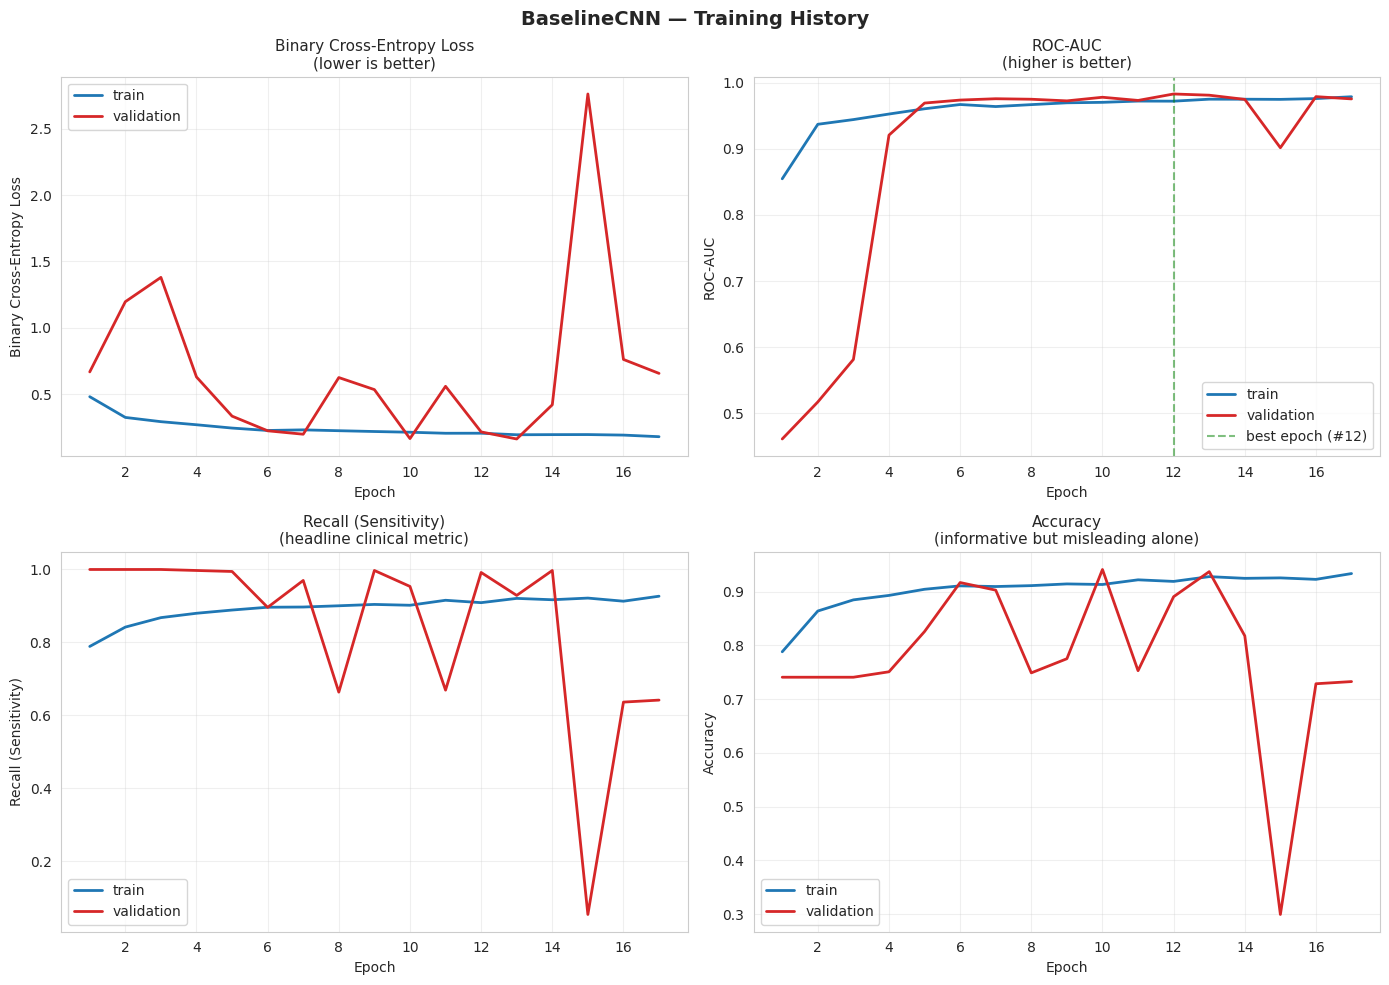

Saved: /content/drive/MyDrive/PneumoniaDetection/reports/figures/fig04_baseline_learning_curves.png

=== Best validation epoch ===
Epoch:        12
val_loss:     0.2145
val_accuracy: 0.8907
val_recall:   0.9918   <-- clinical headline
val_auc:      0.9831
val_pr_auc:   0.9946


In [ ]:
hist = history.history
epochs_ran = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("BaselineCNN — Training History", fontsize=14, weight="bold")

panels = [
    ("loss",      "Binary Cross-Entropy Loss", "lower is better"),
    ("auc",       "ROC-AUC",                   "higher is better"),
    ("recall",    "Recall (Sensitivity)",      "headline clinical metric"),
    ("accuracy",  "Accuracy",                  "informative but misleading alone"),
]

for ax, (key, title, subtitle) in zip(axes.ravel(), panels):
    ax.plot(epochs_ran, hist[key],          label="train",      linewidth=2,  color="#1f77b4")
    ax.plot(epochs_ran, hist[f"val_{key}"], label="validation", linewidth=2,  color="#d62728")

    # Mark the best validation epoch (per AUC) — the checkpoint we'll use downstream
    if key == "auc":
        best_ep = int(np.argmax(hist["val_auc"])) + 1
        ax.axvline(best_ep, linestyle="--", alpha=0.5, color="green",
                   label=f"best epoch (#{best_ep})")

    ax.set_title(f"{title}\n({subtitle})", fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel(title)
    ax.legend(loc="best"); ax.grid(alpha=0.3)

plt.tight_layout()
out = FIGURES_DIR / "fig04_baseline_learning_curves.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

# === Print summary of best epoch ===
best_idx     = int(np.argmax(hist["val_auc"]))
print("\n=== Best validation epoch ===")
print(f"Epoch:        {best_idx + 1}")
print(f"val_loss:     {hist['val_loss'][best_idx]:.4f}")
print(f"val_accuracy: {hist['val_accuracy'][best_idx]:.4f}")
print(f"val_recall:   {hist['val_recall'][best_idx]:.4f}   <-- clinical headline")
print(f"val_auc:      {hist['val_auc'][best_idx]:.4f}")
print(f"val_pr_auc:   {hist['val_pr_auc'][best_idx]:.4f}")